# Vlasov-Poisson 1D: training a PPO controller

This notebook has an adjoining page at
https://pdecontrolgym.readthedocs.io/en/latest/environments/vlasovpoisson-1d.html

The environment is the collisionless 1D1V Vlasov-Poisson system,

$$\partial_t f + v\,\partial_x f + \big(E(x,t) + H(x,t)\big)\,\partial_v f = 0, \qquad
E = -\partial_x \Phi, \quad -\partial_x^2 \Phi = \rho - \rho_{ion}, \quad \rho = \int f\,dv,$$

on a periodic domain $x \in [0, 10\pi]$ with $v \in [-8, 8]$. The state $f(x,v,t)$ is a
distribution over phase space, $E$ is the field the plasma generates itself, and
$H(x,t)$ is the **actuator**: an externally applied electric field.

Two things make this different from the other environments in the gym:

- **It is distributed control, not boundary control.** The spatial domain is periodic, so
  there is no boundary to act through. The agent shapes a field across the whole domain.
- **Most of the state is unreachable in principle.** Vlasov transport is measure
  preserving under any $H$ whatsoever, so mass, every $L^p$ norm of $f$, and the entropy
  are invariants. What a controller can do is suppress the *macroscopic* signature of an
  instability, the electric field and the low-order moments. What it cannot do is erase
  the perturbation.

The task here is to hold the plasma at an unstable two-stream equilibrium $\bar f(v)$,
regulating $\delta f = f - \bar f$. We will build baselines first, including the
training-free feedback law from
[Lu, Wang and Calder (arXiv:2509.23063)](https://arxiv.org/abs/2509.23063), then train PPO
against them.

In [1]:
import gymnasium as gym
import pde_control_gym
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

import stable_baselines3
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback, CallbackList, CheckpointCallback
from stable_baselines3.common.vec_env import DummyVecEnv

from pde_control_gym.src import VlasovPoissonReward
from utils import (
    twoStreamEquilibrium,
    multiplicativePerturbation,
    CancellationController,
    ScaleFreeVlasov,
    runEpisode,
)

In [2]:
# Print Versioning
print("gymnasium         ", gym.__version__)
print("stable_baselines3 ", stable_baselines3.__version__)
print("numpy             ", np.__version__)

gymnasium          1.3.0
stable_baselines3  2.9.0
numpy              2.2.6


## Initializing the gym

The equilibrium is the two-stream distribution of Section 3.2 of the paper, two
counter-streaming Gaussian beams at $\bar v = \pm 2.4$. It is an equilibrium of the
uncontrolled system but a linearly unstable one: the beams pump the electrostatic field
and any perturbation is amplified.

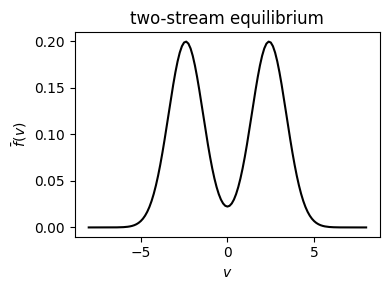

In [3]:
X, nx = 10 * np.pi, 100      # periodic spatial domain and grid
V, nv = 8.0, 129             # truncated velocity domain and grid
T, dt = 30.0, 0.2            # horizon and solver timestep

fbarFunc = twoStreamEquilibrium(vbar=2.4)
xGrid = np.linspace(0, X, nx, endpoint=False)
vGrid = np.linspace(-V, V, nv)
fbar = fbarFunc(xGrid, vGrid)

plt.figure(figsize=(4, 3))
plt.plot(vGrid, fbar[0], "k")
plt.xlabel("$v$")
plt.ylabel(r"$\bar f(v)$")
plt.title("two-stream equilibrium")
plt.tight_layout()
plt.show()

## Which modes are actually unstable?

Before choosing an action space it is worth knowing what needs controlling. Around a
homogeneous $\bar f(v)$ the linearized system decouples in the spatial Fourier index, and
the actuator harmonic $k$ only affects state harmonic $k$. So the actuator has to cover
exactly the harmonics that grow, and no more: extra actuator modes are pure search-space
cost, while missing ones are *exactly* uncontrollable.

The cell below runs the uncontrolled system with a single harmonic seeded and fits the
growth rate of $|E|$.

In [4]:
def makeEnv(initialConditionFunc, sensing="full", numModes=2, gammaCost=0.0):
    '''Builds a Vlasov-Poisson env. normalize=False so ScaleFreeVlasov owns action scaling.'''
    parameters = {
        "T": T,
        "dt": dt,
        "X": X,
        "dx": X / nx,
        "V": V,
        "dv": 2 * V / (nv - 1),
        "reward_class": VlasovPoissonReward(
            fbar=fbar, dx=X / nx, dv=2 * V / (nv - 1),
            gamma=gammaCost, nt=int(round(T / dt)) + 1,
        ),
        "normalize": False,
        "reset_init_condition_func": initialConditionFunc,
        "equilibrium_func": fbarFunc,
        "sensing_type": sensing,
        "action_type": "modal",
        "num_modes": numModes,
        # A uniform H only accelerates the plasma as a whole and cannot suppress a
        # spatial instability, so it is dropped from the action space.
        "include_uniform_mode": False,
        "max_control_value": 1.0,
        "limit_pde_state_size": True,
        "max_state_value": 10.0,
        "control_sample_rate": dt,
        "store_history": False,
    }
    return gym.make("PDEControlGym-VlasovPoisson1D", **parameters)


print(" mode      k    growth rate of |E|   ||df(T)||/||df(0)||")
for mode in range(1, 7):
    env = makeEnv(multiplicativePerturbation(fbarFunc, epsilon=1e-3, mode=mode, X=X))
    zeroAction = np.zeros(env.unwrapped.action_dim)
    _, trace = runEpisode(env, lambda obs: zeroAction)
    t = np.arange(len(trace["electric_energy"])) * dt
    window = (t > 5) & (t < 25)
    rate = np.polyfit(t[window], 0.5 * np.log(trace["electric_energy"][window]), 1)[0]
    ratio = trace["l2_perturbation"][-1] / trace["l2_perturbation"][0]
    print(f"   {mode}    {2 * np.pi * mode / X:.2f}         {rate:+.4f}           {ratio:10.4g}")

 mode      k    growth rate of |E|   ||df(T)||/||df(0)||


   1    0.20         +0.2503                557.5


   2    0.40         +0.1580                25.96


   3    0.60         -0.2722                1.217


   4    0.80         -0.2593                1.146


   5    1.00         -0.0907                1.078
   6    1.20         -0.0294                1.005


Only harmonics 1 and 2 grow; from harmonic 3 up the modes are Landau damped and take care
of themselves. So the training task randomizes over the two unstable harmonics, and the
actuator is given `num_modes=2` with the uniform mode projected out, for an action
dimension of 4.

In [5]:
class InitialConditionSampler:
    r'''Randomizes the seeded unstable harmonic, its amplitude, and its phase per episode.

    Carrying an explicit Generator rather than touching the global numpy state keeps
    evaluation episodes reproducible across policies.
    '''

    def __init__(self, seed):
        self.rng = np.random.default_rng(seed)

    def __call__(self, x, v):
        epsilon = self.rng.uniform(5e-4, 2e-3)
        mode = self.rng.integers(1, 3)
        phase = self.rng.uniform(0, 2 * np.pi)
        modulation = 1 + epsilon * np.cos(2 * np.pi * mode * x / X + phase)
        return modulation[:, None] * fbarFunc(x, v)


EVAL_SEED = 9000
EVAL_EPISODES = 8

## Baselines

Two references. The first is doing nothing, which tells us how bad the instability is. The
second is the training-free cancellation law of Section 4 of the paper,

$$H[\delta f](x) = -\delta E[\delta f](x) + \gamma \int \delta f(x,v)\, \partial_v \bar f(v)\, dv,$$

which cancels the destabilizing part of the self-consistent field and adds a dissipation
term chosen so that $\tfrac{1}{2}\tfrac{d}{dt}\|\delta f\|_2^2 \le 0$ for every
$\gamma > 0$. It needs `sensing_type="full"` because of the velocity integral.

We report the paper's quadratic cost and the geometric mean of the growth factor
$\|\delta f(T)\| / \|\delta f(0)\|$ over a fixed set of evaluation episodes. Geometric,
because the quantity is multiplicative across a spread of growth rates.

In [6]:
def evaluate(buildPolicy, sensing="field", wrap=True, n=EVAL_EPISODES, seed=EVAL_SEED):
    '''Scores a policy on a fixed seed sequence so every policy sees the same episodes.'''
    papers, ratios = [], []
    for i in range(n):
        env = makeEnv(InitialConditionSampler(seed + i), sensing=sensing)
        unwrapped = env.unwrapped
        if wrap:
            env = ScaleFreeVlasov(env)
        paper, trace = runEpisode(env, buildPolicy(unwrapped))
        papers.append(paper)
        ratios.append(trace["l2_perturbation"][-1] / trace["l2_perturbation"][0])
    return np.mean(papers), np.exp(np.mean(np.log(ratios)))


scores = {}
scores["no control"] = evaluate(
    lambda vp: (lambda obs: np.zeros(vp.action_dim)), sensing="full", wrap=False
)
for gamma in [1.0, 4.0, 16.0]:
    scores[f"cancellation gamma={gamma:g}"] = evaluate(
        lambda vp, g=gamma: CancellationController(vp, gamma=g).action,
        sensing="full", wrap=False,
    )

print(f"{'policy':<26} {'paper reward':>14} {'geo-mean growth':>17}")
for name, (paper, ratio) in scores.items():
    print(f"{name:<26} {paper:>14.4e} {ratio:>17.4g}")

policy                       paper reward   geo-mean growth
no control                    -2.6308e+00             117.4
cancellation gamma=1          -3.3079e-04            0.9926
cancellation gamma=4          -2.5851e-04            0.8227
cancellation gamma=16         -1.8494e-04            0.6222


## Conditioning the problem for RL

Handing this environment to PPO as-is does not work, and the reason is worth understanding
rather than working around blindly.

- The perturbation grows by **two to three orders of magnitude within one episode**, so the
  observation $\delta E$ spans that range and the reward $-\tfrac12\|\delta f\|^2$ spans
  its square. A network with fixed weights cannot respond usefully at both ends, and PPO's
  value function spends its capacity on the saturated tail.
- The useful control amplitude is tiny and phase-sensitive. Gaussian exploration at a
  scale comparable to the correct action actively drives the instability, so most rollouts
  are worse than doing nothing.

`ScaleFreeVlasov` in `utils.py` addresses this with three changes: it divides the
observation by its own magnitude and appends $\log_{10}$ of that magnitude; it interprets
the action as a multiple of the same magnitude; and it replaces the reward by the per-step
log growth factor, whose episode sum is $-\log$ of the overall growth.

The second change is not a hack. Section 2.1 of the paper shows via the Pontryagin maximum
principle that the optimal control for the linearized system is a **linear functional of
$\delta f$**, hence positively homogeneous in it. Rescaling by the amplitude is exactly
what lets one fixed set of weights represent that law at every amplitude. Without it, a
network that responds usefully at reset saturates once the instability develops, and no
fixed set of weights covers both ends.

The paper's quadratic cost is still computed and returned under `info["paper_reward"]`, so
it stays the reported metric even though it is not the training signal.

In [7]:
GAIN = 3.0  # an action of +-1 means +-3 times the observed field magnitude

# Sanity check: does the wrapped action space contain a stabilizing policy at all? The
# leading term of the paper's law is H = -dE, and with sensing_type="field" the
# observation *is* dE, so we can write that policy down directly in wrapper coordinates
# and check it holds the perturbation flat. If this failed, no amount of training would help.
def idealFieldCancellation(vp):
    projector = np.linalg.pinv(vp.control_basis)
    return lambda obs: np.clip(-(projector @ obs[:-1]) / GAIN, -1, 1)


scores["ideal -dE"] = evaluate(idealFieldCancellation)
print("ideal -dE inside the wrapper: paper %+.4e   geo-mean growth %.4g"
      % scores["ideal -dE"])

env = ScaleFreeVlasov(makeEnv(InitialConditionSampler(0), sensing="field"), gain=GAIN)
print("observation space", env.observation_space.shape, " action space", env.action_space.shape)
check_env(env)
print("check_env passed")

ideal -dE inside the wrapper: paper -3.7155e-04   geo-mean growth 1.079
observation space (101,)  action space (4,)
check_env passed


## Training PPO

`trainWithCurve` trains in chunks and scores the deterministic policy on the fixed
evaluation episodes after each chunk. That gives a learning curve in the unit we actually
care about, the growth factor, rather than only in shaped reward.

Two settings are worth explaining before the run.

**`net_arch=[64, 64]` with `lr=3e-4`.** The learning rate is tied to the architecture here
and cannot be carried over from elsewhere. At `lr=1e-3` this same network diverges,
reaching growth factors of 74 and 135 by 400k steps on two seeds, and wider networks are
worse still: `net_arch=[256, 256]` settles around 900, which is worse than applying no
control at all. Use tanh rather than ReLU, too. A tanh network near initialization is close
to a linear map, which is roughly where a good policy for this problem lives.

**`log_std_init=-1.5`.** This keeps the initial exploration below the useful control
amplitude. Left at the default, exploration destabilizes the plasma faster than the
learning signal can accumulate and the run never recovers.

In [8]:
class RewardLoggingCallback(BaseCallback):
    '''Logs the mean shaped reward to TensorBoard and keeps a history for plotting.'''

    def __init__(self, verbose=0):
        super(RewardLoggingCallback, self).__init__(verbose)
        self.history = []

    def _on_step(self):
        mean = float(np.mean(self.locals["rewards"]))
        self.logger.record("reward", mean)
        self.history.append(mean)
        return True


N_ENVS = 4
EVAL_EVERY = 50_000


def trainWithCurve(name, netArch, learningRate, totalTimesteps, seed=0, logStdInit=-1.5):
    '''Trains one PPO agent, evaluating every EVAL_EVERY steps. Returns model and curves.'''
    vecEnv = DummyVecEnv(
        [
            (lambda rank=i: ScaleFreeVlasov(
                makeEnv(InitialConditionSampler(100 + rank), sensing="field"), gain=GAIN
            ))
            for i in range(N_ENVS)
        ]
    )
    rewardLogger = RewardLoggingCallback()
    callbacks = CallbackList([
        CheckpointCallback(save_freq=100_000, save_path=f"./logsPPO/{name}",
                           name_prefix="rl_model"),
        rewardLogger,
    ])
    model = PPO(
        "MlpPolicy", vecEnv, verbose=0, seed=seed,
        n_steps=256, batch_size=256, learning_rate=learningRate, ent_coef=0.0,
        tensorboard_log="./tb/",
        policy_kwargs=dict(net_arch=netArch, log_std_init=logStdInit),
    )
    nParams = sum(p.numel() for p in model.policy.parameters())
    curve = []
    for step in range(EVAL_EVERY, totalTimesteps + 1, EVAL_EVERY):
        model.learn(total_timesteps=EVAL_EVERY, reset_num_timesteps=False,
                    callback=callbacks)
        _, ratio = evaluate(lambda vp: (lambda obs: model.predict(obs, deterministic=True)[0]))
        curve.append((step, ratio))
    model.save(f"vlasovPoisson1D_{name}")
    curve = np.array(curve)
    late = np.median(curve[-3:, 1])
    print(f"{name}: {nParams} policy parameters")
    print(f"  final growth factor {curve[-1][1]:.3f}, median of last three checkpoints {late:.3f}")
    return model, np.array(rewardLogger.history), curve

In [9]:
TOTAL_TIMESTEPS = 600000  # roughly 20 minutes on a laptop; see the last section

model, rewardHistory, curve = trainWithCurve(
    "mlp", netArch=[64, 64], learningRate=3e-4, totalTimesteps=TOTAL_TIMESTEPS
)

mlp: 21705 policy parameters
  final growth factor 1.221, median of last three checkpoints 1.221


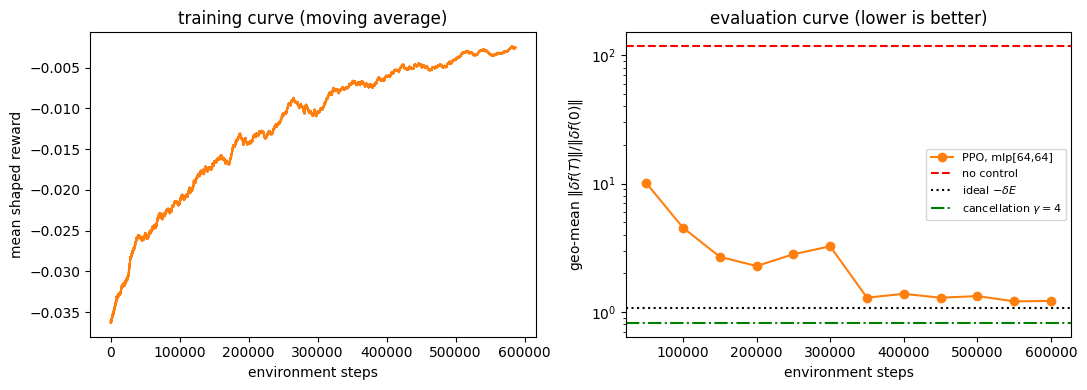

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

window = max(1, len(rewardHistory) // 40)
smoothed = np.convolve(rewardHistory, np.ones(window) / window, mode="valid")
axes[0].plot(np.arange(len(smoothed)) * N_ENVS, smoothed, "C1")
axes[0].set_xlabel("environment steps")
axes[0].set_ylabel("mean shaped reward")
axes[0].set_title("training curve (moving average)")

axes[1].semilogy(curve[:, 0], curve[:, 1], "C1o-", label="PPO, mlp[64,64]")
axes[1].axhline(scores["no control"][1], color="r", ls="--", label="no control")
axes[1].axhline(scores["ideal -dE"][1], color="k", ls=":", label=r"ideal $-\delta E$")
axes[1].axhline(scores["cancellation gamma=4"][1], color="g", ls="-.",
                label=r"cancellation $\gamma=4$")
axes[1].set_xlabel("environment steps")
axes[1].set_ylabel(r"geo-mean $\|\delta f(T)\| / \|\delta f(0)\|$")
axes[1].set_title("evaluation curve (lower is better)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Evaluation

Same fixed evaluation episodes as the baselines, so the numbers are directly comparable.
Single checkpoints are noisy, so read the curve above rather than the final row alone.

In [11]:
scores["PPO"] = evaluate(lambda vp: (lambda obs: model.predict(obs, deterministic=True)[0]))

print(f"{'policy':<26} {'paper reward':>14} {'geo-mean growth':>17}")
for name, (paper, ratio) in scores.items():
    print(f"{name:<26} {paper:>14.4e} {ratio:>17.4g}")

policy                       paper reward   geo-mean growth
no control                    -2.6308e+00             117.4
cancellation gamma=1          -3.3079e-04            0.9926
cancellation gamma=4          -2.5851e-04            0.8227
cancellation gamma=16         -1.8494e-04            0.6222
ideal -dE                     -3.7155e-04             1.079
PPO                           -4.3674e-04             1.221


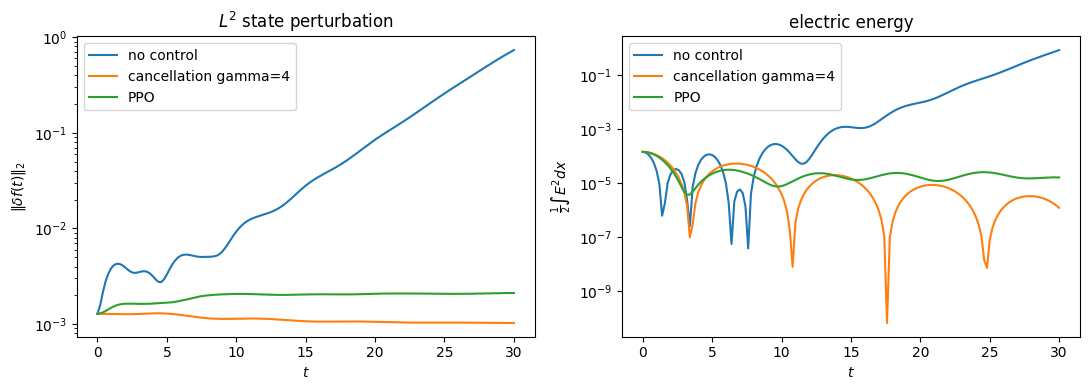

In [12]:
# Single-episode trajectories on a common initial condition, for plotting.
def singleEpisode(buildPolicy, sensing="field", wrap=True, seed=EVAL_SEED):
    env = makeEnv(InitialConditionSampler(seed), sensing=sensing)
    unwrapped = env.unwrapped
    if wrap:
        env = ScaleFreeVlasov(env, gain=GAIN)
    paper, trace = runEpisode(env, buildPolicy(unwrapped))
    trace["final_df"] = unwrapped.f_current - unwrapped.fbar
    return trace


runs = {
    "no control": singleEpisode(lambda vp: (lambda o: np.zeros(vp.action_dim)),
                                sensing="full", wrap=False),
    "cancellation gamma=4": singleEpisode(
        lambda vp: CancellationController(vp, gamma=4.0).action, sensing="full", wrap=False),
    "PPO": singleEpisode(lambda vp: (lambda o: model.predict(o, deterministic=True)[0])),
}

t = np.arange(len(runs["no control"]["l2_perturbation"])) * dt
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, trace in runs.items():
    axes[0].semilogy(t, trace["l2_perturbation"], label=name)
    axes[1].semilogy(t, trace["electric_energy"], label=name)
axes[0].set_xlabel("$t$"); axes[0].set_ylabel(r"$\|\delta f(t)\|_2$")
axes[0].set_title("$L^2$ state perturbation"); axes[0].legend()
axes[1].set_xlabel("$t$"); axes[1].set_ylabel(r"$\frac{1}{2}\int E^2 dx$")
axes[1].set_title("electric energy"); axes[1].legend()
plt.tight_layout()
plt.show()

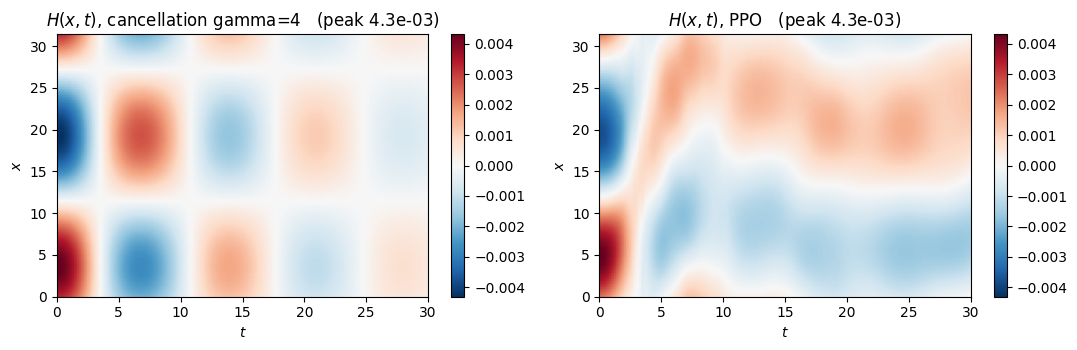

In [13]:
# The control signals the two feedback laws actually apply.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, name in zip(axes, ["cancellation gamma=4", "PPO"]):
    H = runs[name]["H"]
    limit = np.abs(H).max() + 1e-30
    image = ax.imshow(H.T, origin="lower", aspect="auto", cmap="RdBu_r",
                      vmin=-limit, vmax=limit, extent=[0, T, 0, X])
    ax.set_title(f"$H(x,t)$, {name}   (peak {limit:.1e})")
    ax.set_xlabel("$t$"); ax.set_ylabel("$x$")
    fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

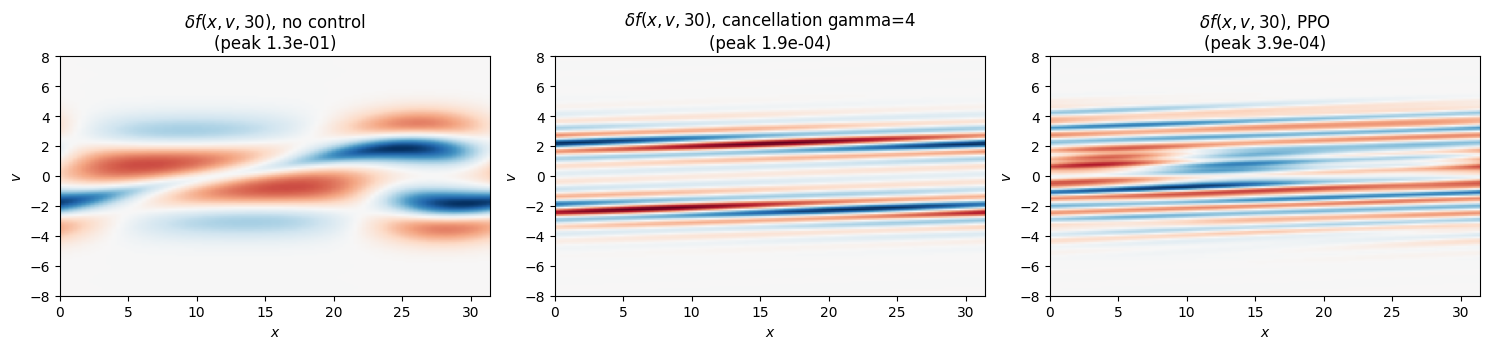

In [14]:
# Phase space at the end of the episode.
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (name, trace) in zip(axes, runs.items()):
    df = trace["final_df"]
    limit = np.abs(df).max() + 1e-30
    ax.imshow(df.T, origin="lower", aspect="auto", cmap="RdBu_r",
              vmin=-limit, vmax=limit, extent=[0, X, -V, V])
    ax.set_title(f"$\\delta f(x,v,{T:.0f})$, {name}\n(peak {limit:.1e})")
    ax.set_xlabel("$x$"); ax.set_ylabel("$v$")
plt.tight_layout()
plt.show()

## Where to go from here

Things that move the needle, roughly in order:

- **More timesteps.** The budget above is set so the notebook finishes quickly. The
  pretrained models for the other environments in this repository were trained for
  1.5M steps; expect to need that order here too.
- **Change the architecture and the learning rate together.** They are not independent
  on this problem. The network above needs `lr=3e-4`; at `lr=1e-3` it diverges. Shrinking
  the network lets you raise the rate: a bare `net_arch=[]` trains stably at `lr=1e-3` and
  reaches the same growth factor in roughly a third of the samples. That is expected
  rather than surprising, since the optimum for the linearized problem is a
  400-parameter linear map, so the capacity above is not what is doing the work.
- **Tune `GAIN` and `log_std_init` together.** They set how much authority the agent has
  and how hard it explores. Too much of either and exploration destabilizes the plasma
  faster than the learning signal can accumulate.
- **Harder sensing.** `sensing_type="field"` hands the agent exactly the quantity it must
  cancel. `"density"` gives $\delta\rho$ and is a fair bit harder; `"moments"` and
  `"full"` are the other options. Note that the dissipation term of the paper's law needs
  `"full"` sensing, while the $-\delta E$ term is a functional of $\delta\rho$ alone.
- **Noisy diagnostics.** Pass a `sensing_noise_func` to reproduce Section 3.4 of the
  paper, where the neural-operator controller degrades noticeably once the noise reaches
  half the initial perturbation amplitude but the cancellation law stays robust.

And two limits that no amount of training removes, both quantified in
`vlasovPoisson1DtestSolver.py`:

- The actuator is a function of $x$ only, so at any instant it reaches at most $n_x$ of
  the $n_x n_v$ state directions, and only the component of $\delta f$ aligned with
  $\partial_v \bar f$ is actuated directly. The multiplicative initial condition used here
  and in the paper is *exactly orthogonal* to $\partial_v \bar f$ at $t = 0$.
- Every Casimir of $f$ is invariant under any control, so $\|\delta f\|_2 \to 0$ is not
  achievable unless $f_0$ happens to be a measure-preserving rearrangement of $\bar f$.
  Suppressing the field and the low-order moments is the achievable goal.